In [ ]:
import pandas as pd
import glob
import numpy as np
import scanpy as sc
import anndata
from scipy.stats import entropy
import harmonypy

MIN_GENES = 1000
MAX_GENES = 6000
MIN_UMI = 6000
MAX_UMI = 75000
MIN_ENT = 5.5

files = sorted(glob.glob('/data/GSE157504/*.csv'))
adatas = []
for f in files:
    adata = sc.AnnData(pd.read_csv(f, index_col=0).T)
    # 
    replicate = f.split('/')[-1].split('.')[0].split('_')[-1]
    time = int(f.split('_')[-3][2:])
    if "ZT" in f:
        condition = "LD"
    elif "CT" in f:
        condition = "DD"
    adata.obs['replicate'] = replicate
    adata.obs['time'] = time
    adata.obs['condition'] = condition
    adata.obs['key'] = f"{replicate}_{condition}"
    # Filter out low-quality cells
    sc.pp.filter_cells(adata, min_genes=MIN_GENES)
    sc.pp.filter_cells(adata, max_genes=MAX_GENES)
    sc.pp.filter_cells(adata, min_counts=MIN_UMI)
    sc.pp.filter_cells(adata, max_counts=MAX_UMI)
    adata.obs['ent'] = entropy(adata.X, axis=1)
    adata = adata[adata.obs['ent'] > MIN_ENT].copy()
    # Select highly variable genes and normalize
    sc.experimental.pp.highly_variable_genes(adata, n_top_genes=3000, subset=True)
    sc.experimental.pp.normalize_pearson_residuals(adata)
    adatas.append(adata)
# Filter mitochondral, ribosomal, and tRNA genes, and integrate samples
key = 'replicate'
adatas = sorted(adatas, key=lambda x: x.obs[key][0])
adata = anndata.concat(adatas, axis=0, label="batch", keys=[f.split('/')[-1].split('.')[0] for f in files])
is_mt = adata.var_names.str.contains("MT") | adata.var_names.str.contains("mt")
is_rp = adata.var_names.str.contains("RPL") | adata.var_names.str.contains("RPS") | adata.var_names.str.contains("rRNA")
is_trna = adata.var_names.str.contains("TRN") | adata.var_names.str.contains("trn")
adata = adata[:, ~(is_mt | is_rp | is_trna)].copy()
sc.pp.pca(adata, n_comps=50)

harmony_out = harmonypy.run_harmony(adata.obsm['X_pca'], adata.obs, key, theta=1.0)
adata.obsm["X_pca_harmony"] = harmony_out.Z_corr
X_raw = adata.obsm['X_pca_harmony']

/tmp/ipykernel_15345/1197077838.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adatas = sorted(adatas, key=lambda x: x.obs[key][0])
2026-06-14 21:57:11,035 - harmonypy - INFO - Running Harmony
2026-06-14 21:57:11,036 - harmonypy - INFO -   Parameters:
2026-06-14 21:57:11,037 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-14 21:57:11,037 - harmonypy - INFO -     max_iter_kmeans: 4
2026-06-14 21:57:11,038 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-06-14 21:57:11,038 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-06-14 21:57:11,039 - harmonypy - INFO -     nclust: 100
2026-06-14 21:57:11,039 - harmonypy - INFO -     block_size: 0.05
2026-06-14 21:57:11,040 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-06-14 21:57:11,040 - harmonypy - INFO -     theta: [1. 1. 1. 1. 1.

In [ ]:
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.gaussian_process.kernels import RBF
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

seed = 0
np.random.seed(seed)

X = umap.UMAP(n_components=10, n_neighbors=30, min_dist=1.0, random_state=seed).fit_transform(X_raw)
F = adata.X
F_names = adata.var_names

# ensure a color is available for each unique batch
fig, ax = plt.subplots(2, 3, figsize=(12,6))
ax[0, 0].scatter(X[:, 0], X[:, 1], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
ax[0, 1].scatter(X[:, 0], X[:, 2], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
ax[0, 2].scatter(X[:, 0], X[:, 3], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
ax[1, 0].scatter(X[:, 1], X[:, 2], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
ax[1, 1].scatter(X[:, 1], X[:, 3], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
sc = ax[1, 2].scatter(X[:, 2], X[:, 3], c=adata.obs['time'], s=2, alpha=0.5, cmap='twilight_shifted')
plt.colorbar(sc, ax=ax.ravel().tolist(), shrink=0.6, label='Time')
fig.suptitle("Preprocessed data")

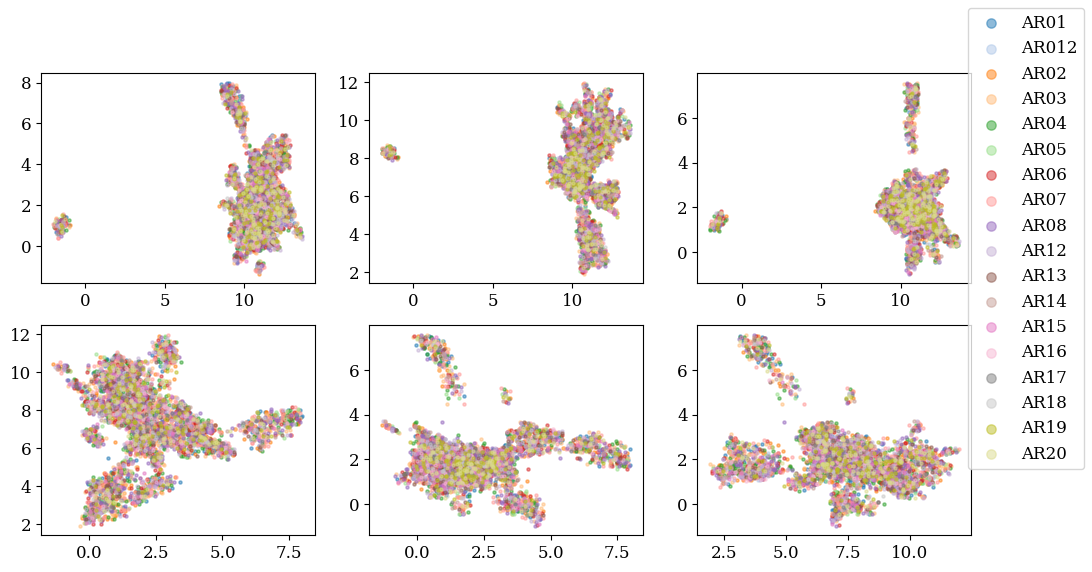

In [4]:
color = 'replicate'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.colormaps['tab20'].colors)
c_dict = {c: i for i, c in enumerate(adata.obs[color].unique())}
fig, ax = plt.subplots(2, 3, figsize=(12,6))
for batch in adata.obs[color].unique():
    batch_mask = adata.obs[color] == batch
    ax[0, 0].scatter(X[batch_mask, 0], X[batch_mask, 1], s=5, alpha=0.5)
    ax[0, 1].scatter(X[batch_mask, 0], X[batch_mask, 2], s=5, alpha=0.5)
    ax[0, 2].scatter(X[batch_mask, 0], X[batch_mask, 3], s=5, alpha=0.5)
    ax[1, 0].scatter(X[batch_mask, 1], X[batch_mask, 2], s=5, alpha=0.5)
    ax[1, 1].scatter(X[batch_mask, 1], X[batch_mask, 3], s=5, alpha=0.5)
    ax[1, 2].scatter(X[batch_mask, 2], X[batch_mask, 3], s=5, alpha=0.5)
fig.legend(adata.obs[color].unique(), loc='upper right', markerscale=3)

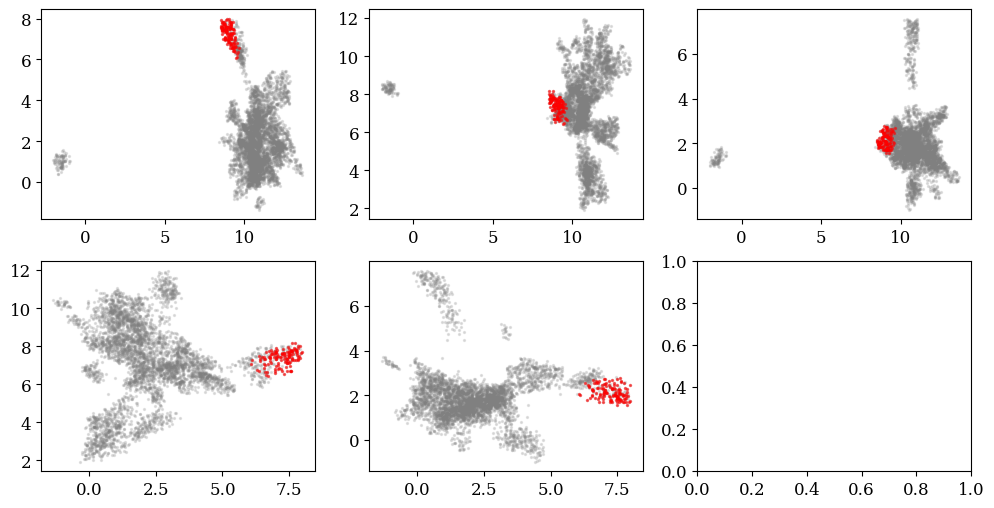

In [ ]:
r = 1.0
knn = 128
neighbor_graph = kneighbors_graph(X, knn, include_self=True)

index = 6
neighborhood = neighbor_graph[index].nonzero()[1]
fig, ax = plt.subplots(2, 3, figsize=(12,6))
ax[0, 0].scatter(X[:, 0], X[:, 1], c='gray', s=2, alpha=0.2)
ax[0, 1].scatter(X[:, 0], X[:, 2], c='gray', s=2, alpha=0.2)
ax[0, 2].scatter(X[:, 0], X[:, 3], c='gray', s=2, alpha=0.2)
ax[1, 0].scatter(X[:, 1], X[:, 2], c='gray', s=2, alpha=0.2)
ax[1, 1].scatter(X[:, 1], X[:, 3], c='gray', s=2, alpha=0.2)

ax[0, 0].scatter(X[neighborhood, 0], X[neighborhood, 1], c='red', s=2, alpha=0.5)
ax[0, 1].scatter(X[neighborhood, 0], X[neighborhood, 2], c='red', s=2, alpha=0.5)
ax[0, 2].scatter(X[neighborhood, 0], X[neighborhood, 3], c='red', s=2, alpha=0.5)
ax[1, 0].scatter(X[neighborhood, 1], X[neighborhood, 2], c='red', s=2, alpha=0.5)
ax[1, 1].scatter(X[neighborhood, 1], X[neighborhood, 3], c='red', s=2, alpha=0.5)

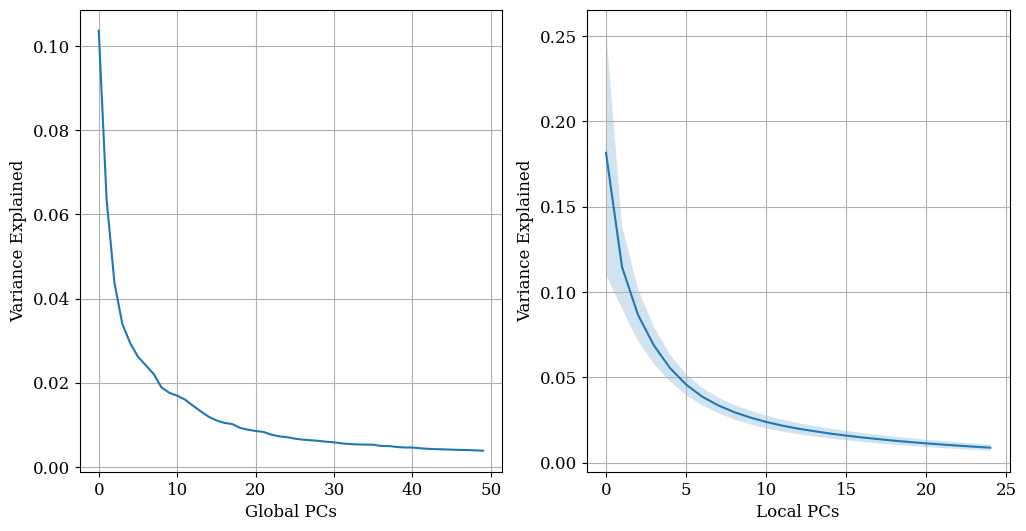

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].plot(adata.uns['pca']['variance_ratio'])
ax[0].set_xlabel('Global PCs')
ax[0].set_ylabel('Variance Explained')
ax[0].grid()

local_var_explained_ratios = []
for index in range(X.shape[0]):
    nbr_ind = neighbor_graph[index].nonzero()[1]
    pca = PCA(n_components=25).fit(X_raw[nbr_ind])
    local_var = pca.explained_variance_ratio_
    local_var_explained_ratios.append(local_var)
local_var_explained_ratios = np.stack(local_var_explained_ratios)
mean_var_explained = np.mean(local_var_explained_ratios, axis=0)
std_var_explained = np.std(local_var_explained_ratios, axis=0)
ax[1].plot(mean_var_explained)
ax[1].fill_between(range(len(mean_var_explained)), mean_var_explained - std_var_explained, mean_var_explained + std_var_explained, alpha=0.2)
ax[1].set_xlabel('Local PCs')
ax[1].set_ylabel('Variance Explained')
ax[1].grid()

In [ ]:
import sys
sys.path.append('../')
from lego import lego

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet

from local_ts_regression import lpca, run_ts_regression_smoothed

d = 2

trivial_basis = np.stack([np.eye(X.shape[1])] * X.shape[0], axis=0)
lpca_basis = lpca(X, d, neighbor_graph)
wlpca_basis = lpca(X, d, neighbor_graph, r=1.0)

ts_method = 'lego'
n_eig_for_grad = 40
n_eig = 100
lego_estimate = lego.lego(
    X,
    opts={'emb_dim': d, 'k_nn': knn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)
lego_basis = lego_estimate['tang_basis']

Support Features: ['Con', 'Appl', 'CG45263', 'CG43729']


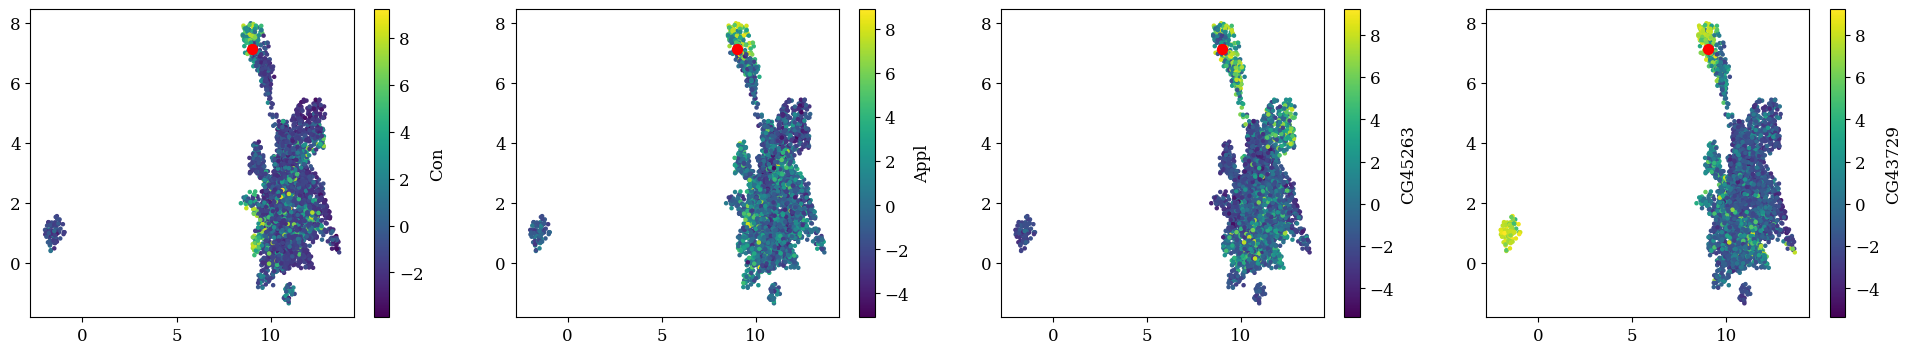

In [ ]:
index = 6

n_feats = 4
# tsbasis = trivial_basis
# tsbasis = lpca_basis
# tsbasis = wlpca_basis
tsbasis = lego_basis

normalizer = StandardScaler(with_mean=False)
regressor = MultiTaskElasticNet(alpha=0.1, l1_ratio=0.5, fit_intercept=False)

reg_coefs, proj = run_ts_regression_smoothed(X, F, index, neighbor_graph, tsbasis, regressor=regressor, gamma=1.0, k=1)
strengths = np.linalg.norm(reg_coefs, axis=0)
support = np.argsort(strengths)[-1:-n_feats-1:-1]
fig, ax = plt.subplots(1, len(support), figsize=(6*len(support), 4))
for i in range(len(support)):
    sc = ax[i].scatter(X[:, 0], X[:, 1], c = F[:,support[i]], s=5, cmap='viridis')
    ax[i].scatter(X[index, 0], X[index, 1], c = 'red', s=50)
    fig.colorbar(sc, ax=ax[i], label=F_names[support[i]])
print(f'Support Features: {[F_names[i] for i in support]}')

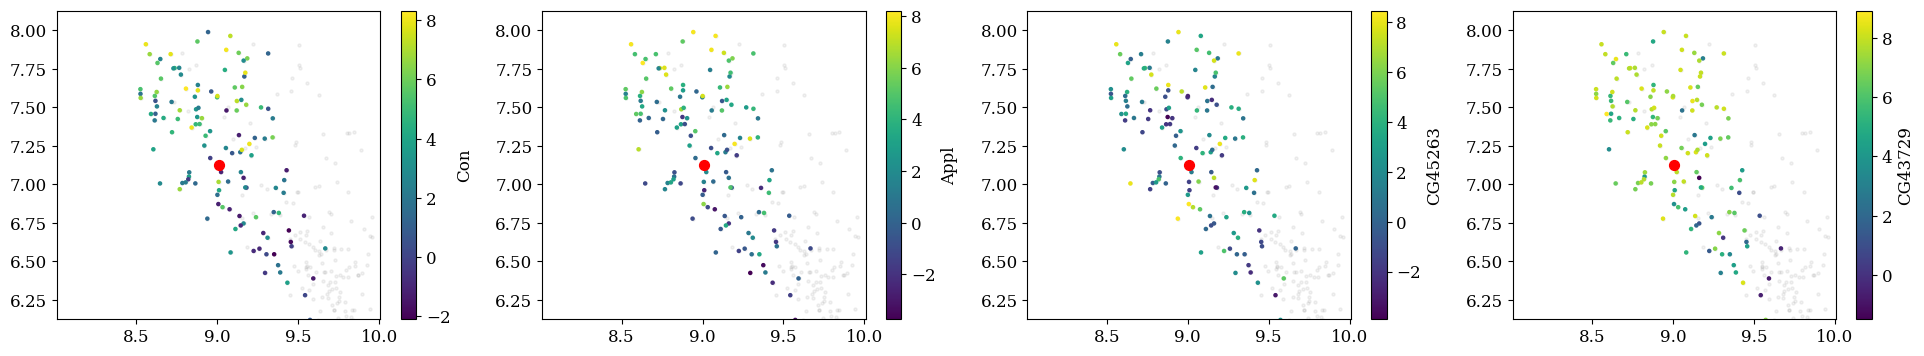

In [10]:
nbr_ind = neighbor_graph[index].nonzero()[1]
fig, ax = plt.subplots(1, len(support), figsize=(6*len(support), 4))
for i in range(len(support)):
    ax[i].scatter(X[:, 0], X[:, 1], c = 'gray', s=5, alpha=0.1)
    sc = ax[i].scatter(X[nbr_ind, 0], X[nbr_ind, 1], c = F[nbr_ind,support[i]], s=5, cmap='viridis')
    
    ax[i].scatter(X[index, 0], X[index, 1], c = 'red', s=50)
    ax[i].set_xlim(X[index, 0] - 1.0, X[index, 0] + 1.0)
    ax[i].set_ylim(X[index, 1] - 1.0, X[index, 1] + 1.0)
    fig.colorbar(sc, ax=ax[i], label=F_names[support[i]])

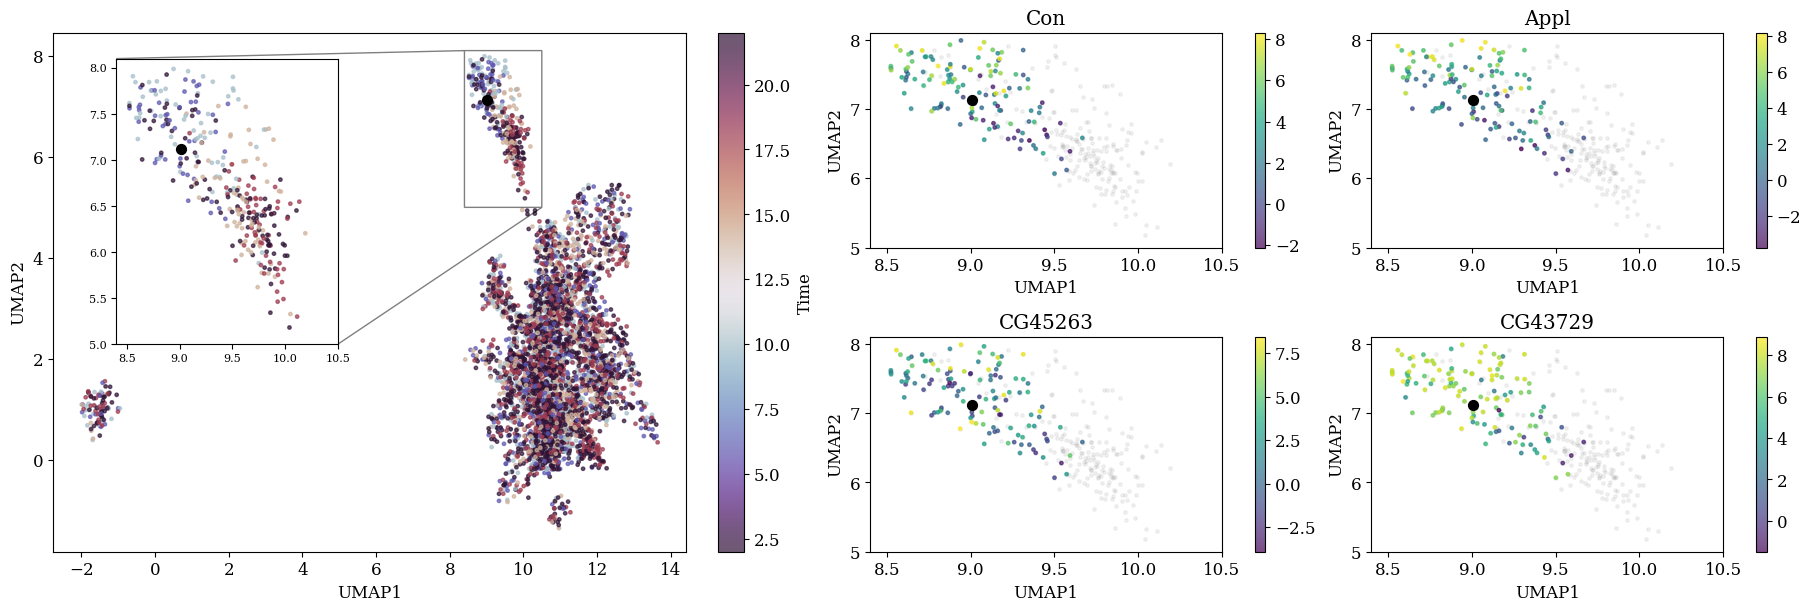

In [21]:
window_xlim = (8.4, 10.5)
window_ylim = (5, 8.1)

fig = plt.figure(figsize=(18, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1.8, 1, 1])

ax_time = fig.add_subplot(gs[:, 0])
gene_axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

sc_time = ax_time.scatter(
    X[:, 0], X[:, 1],
    c=adata.obs['time'],
    s=6,
    alpha=0.7,
    cmap='twilight_shifted'
)
ax_time.scatter(
    X[index, 0], X[index, 1],
    c='black',
    s=50,
)
ax_time.set_xlabel('UMAP1')
ax_time.set_ylabel('UMAP2')
fig.colorbar(sc_time, ax=ax_time, label='Time')

axins = ax_time.inset_axes([0.1, 0.4, 0.35, 0.55])
axins.scatter(
    X[:, 0], X[:, 1],
    c=adata.obs['time'],
    s=6,
    alpha=0.7,
    cmap='twilight_shifted'
)
axins.scatter(
    X[index, 0], X[index, 1],
    c='black',
    s=50,
)
axins.set_xlim(window_xlim)
axins.set_ylim(window_ylim)
# axins.set_title('Zoom', fontsize=10)
axins.tick_params(labelsize=8)

ax_time.indicate_inset_zoom(axins, edgecolor='black')

for ax, gene_idx in zip(gene_axes, support):
    gene_values = np.asarray(F[:, gene_idx]).ravel()
    ax.scatter(
        X[:, 0], X[:, 1],
        c='gray',
        s=6,
        alpha=0.1
    )
    sc_gene = ax.scatter(
        X[nbr_ind, 0], X[nbr_ind, 1],
        c=gene_values[nbr_ind],
        s=6,
        alpha=0.7,
        cmap='viridis'
    )
    ax.scatter(
        X[index, 0], X[index, 1],
        c='black',
        s=50,
    )
    ax.set_xlim(window_xlim)
    ax.set_ylim(window_ylim)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    ax.set_title(F_names[gene_idx])
    fig.colorbar(sc_gene, ax=ax, fraction=0.046, pad=0.04)

plt.savefig(f'../images/circadian_explanation_{index}.png', dpi=300, bbox_inches='tight')
plt.show()